### An EDA of our dataset Xeno-Canto A-M

#### DF as is: Describe, Info

In [38]:
from aivian.data import get_dataset_path
import pandas as pd


root = get_dataset_path()
csvs = sorted(root.rglob("*.csv"))
print(csvs)

NA_STRINGS = [
    "Not specified", "not specified", "Not Specified",
    "Not included", "not included", "Not Included",
    "Not applicable", "not applicable", "Not Applicable",
    "Unknown", "unknown", "?", "-", "--", "none", "null", "Null", "Null:0", "n.a.", "N.A.",
    "0000-00-00",
]

df = pd.read_csv(csvs[0], na_values=NA_STRINGS, low_memory=False)
df.info()

[WindowsPath('C:/Users/joano/.cache/kagglehub/datasets/rohanrao/xeno-canto-bird-recordings-extended-a-m/versions/11/train_extended.csv')]
<class 'pandas.DataFrame'>
RangeIndex: 23784 entries, 0 to 23783
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rating            23784 non-null  float64
 1   playback_used     21938 non-null  str    
 2   ebird_code        23784 non-null  str    
 3   channels          23784 non-null  str    
 4   date              23761 non-null  str    
 5   duration          23784 non-null  int64  
 6   filename          23784 non-null  str    
 7   species           23784 non-null  str    
 8   title             23784 non-null  str    
 9   secondary_labels  23784 non-null  str    
 10  bird_seen         21827 non-null  str    
 11  sci_name          23784 non-null  str    
 12  location          23782 non-null  str    
 13  latitude          23359 non-null  float64
 14  samplin

In [39]:
df.describe(include ='all')

,rating,playback_used,ebird_code,channels,date,duration,filename,species,title,secondary_labels,...,background,xc_id,url,country,author,primary_label,longitude,time,recordist,license
count,23784.000000,21938,23784,23784,23761,23784.000000,23784,23784,23784,23784,...,11018,23784.000000,23784,23784,23782,23784,23359.000000,22518,23782,23784
unique,NaN,2,259,2,3696,NaN,23784,259,23784,6464,...,6463,NaN,23784,103,1486,259,NaN,1869,1486,4
top,NaN,no,redcro,2 (stereo),2020-07-19,NaN,XC554809.mp3,Red Crossbill,XC554809 Alder Flycatcher (Empidonax alnorum),[],...,Red-winged Blackbird (Agelaius phoeniceus),NaN,https://www.xeno-canto.org/554809,United States,Richard E. Webster,Loxia curvirostra_Red Crossbill,NaN,08:00,Richard E. Webster,Creative Commons Attribution-NonCommercial-Sha...
freq,NaN,21439,1772,13539,86,NaN,1,1772,1,12766,...,150,NaN,1,13103,1652,1772,NaN,1056,1652,20404
mean,3.256496,NaN,NaN,NaN,NaN,54.498234,NaN,NaN,NaN,NaN,...,NaN,380028.124243,NaN,NaN,NaN,NaN,-70.530775,NaN,NaN,NaN
std,1.217350,NaN,NaN,NaN,NaN,85.703448,NaN,NaN,NaN,NaN,...,NaN,156529.646435,NaN,NaN,NaN,NaN,56.833730,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,245.000000,NaN,NaN,NaN,NaN,-165.405300,NaN,NaN,NaN
25%,2.500000,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,...,NaN,254442.000000,NaN,NaN,NaN,NaN,-112.330500,NaN,NaN,NaN
50%,3.500000,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,...,NaN,393016.000000,NaN,NaN,NaN,NaN,-87.010000,NaN,NaN,NaN
75%,4.000000,NaN,NaN,NaN,NaN,63.000000,NaN,NaN,NaN,NaN,...,NaN,532036.000000,NaN,NaN,NaN,NaN,-49.005100,NaN,NaN,NaN


#### Evaluating by Searching Nan and Alt-Nan (ie: 'Non Applicable's) and Duplicate entries

In [40]:
df.isna().sum()

rating                  0
playback_used        1846
ebird_code              0
channels                0
date                   23
duration                0
filename                0
species                 0
title                   0
secondary_labels        0
bird_seen            1957
sci_name                0
location                2
latitude              425
sampling_rate           0
type                   36
elevation               0
bitrate_of_mp3          0
file_type               0
background          12766
xc_id                   0
url                     0
country                 0
author                  2
primary_label           0
longitude             425
time                 1266
recordist               2
license                 0
dtype: int64

In [41]:
for col in df.columns:
    n = df[col].nunique(dropna=False)
    print(f"\n{col} ({n} unique)\nNull:{df[col].isna().sum()}")
    print(df[col].value_counts(dropna=False))


rating (11 unique)
Null:0
rating
3.5    4920
4.0    4782
3.0    3611
2.5    2675
4.5    2150
5.0    2061
0.0    1413
2.0    1187
1.5     612
1.0     251
0.5     122
Name: count, dtype: int64

playback_used (3 unique)
Null:1846
playback_used
no     21439
NaN     1846
yes      499
Name: count, dtype: int64

ebird_code (259 unique)
Null:0
ebird_code
redcro     1772
houspa     1216
houwre      984
comrav      889
eursta      694
           ... 
norhar2       1
rinduc        1
rufgro        1
shshaw        1
swahaw        1
Name: count, Length: 259, dtype: int64

channels (2 unique)
Null:0
channels
2 (stereo)    13539
1 (mono)      10245
Name: count, dtype: int64

date (3697 unique)
Null:23
date
2020-07-19    86
2020-05-21    74
2020-04-25    69
2018-06-08    66
2020-04-19    60
              ..
2016-09-03     1
2010-08-05     1
2009-04-25     1
2011-06-19     1
2000-10-20     1
Name: count, Length: 3697, dtype: int64

duration (551 unique)
Null:0
duration
10     542
6      456
12     445


In [7]:
dupes = df[df.duplicated(keep=False)]
print(len(dupes), "rows involved in exact duplication")
dupes

0 rows involved in exact duplication


,rating,playback_used,ebird_code,channels,date,duration,filename,species,title,secondary_labels,...,background,xc_id,url,country,author,primary_label,longitude,time,recordist,license


#### Further evaluationg data before converting to graphable values
Goind down the list of our columns from .isna().sum()
- Rating, 0-5, most likely not going to be used except to train the model in stages. ie: training and test
with rate 5 recordings and then 4, 3, 2, 1
    - Cell below is an example of a rating 0 recording
    - Possible reason(s) for rating: long pauses between bird calls
- Playback_used Nan entries only accounts for 8% of the column's data
    - You can hear people making bird calls in the background to provoke the bird, though the bird comes out much clearer
    - rating is also 0.0
    - Unlikely but not impossible that a conflicting bird species cry was used
    - ie: House Sparrows vs Eastern Bluebird
- Ebird_code refers to an online system used to embed recordings into the xeno-canto database
    - fun fact: sometimes embedded with a spectogram
- Channels refer to Mono or Stereo
    - Cell below fetches the first instance of 
- Date is formatted as Year-month-date of recording
    - not super clear if that's date the recording was uploaded to xeno-canto or if that's date of recording
- Duration is the length of the recording in seconds
- Filename is the name of the mp3 file
- Species is the name of the bird Species:
    - ie: Alder Flycatcher
- Title is a collection of the Filename(sans .mp3) Species name and Scientific name
    - ie: XC554809 Alder Flycatcher (Empidonax alnorum)
- Labels (primary and Secondary) 
    - Two bird species possibly one bird that was intended to be viewed and a second call that could be heard in the recording
    - Also possibly one main species and a sub species of birds
    - from Kaggle BirdCall Clef 2021 competition forum: "Typically is the primary label is the bird that you hear loudest / most often, but it could just be the one that the author was most interested in / was watching at the time. Secondary labels are moderately sparse and indicate other birds that can also be heard in the recording."
- Bird seen is denoted with yes or no
- Scientific name is what it is
- Location is usually denoted with City Name (maybe a note ie: "near leamington"), County, State
- Country is it's own thing not included in Location
- Latitude and longitude as are
- Sampling_rate -- str hertz -- "the number of times per second an analog sound wave is measured and converted into a digital value"
    - this may vary depending on background noise, extended periods of silence
    - and the variation of purpose in bird calls
    - ie: territorial display, mating, nesting, etc
- Type is a description of the call itself and can greatly vary, may include age, gender, purpose:
    - ie:
        - "call"
        - "adult, call, male"
        - adult, begging call, hatchling or nestling, sex uncertain, song
        - adult, call, colony sounds, female, male, song
        - Chip, call
        - 3 part trill, song
        - "Tchik", call, female, male
- Elevation is height above sea level where audio was captured (str type, honestly could've been an int)
    - ie: 70m
- Bitrate_of_mp3 (according to gemini) -- Also a str column (╯°□°)╯︵ ┻━┻
    - "The bit rate of an MP3 is the amount of digital audio data processed per second, usually measured in kilobits per second (kbps)"
    - "96 kbps to 128 kbps: Low to basic quality. It works for voice recordings or saving space, but music can sound thin or fuzzy"
- File_type - a str type -- all of these are mp3 with no Nan values
    - will drop this as file type has no effect on predictions
- Background -- functions the same as secondary labels but may include the species name and scientific name
    - or empty string
    - or a list separated by a semicolon
    - ie: 
    - or: Great Crested Flycatcher (Myiarchus crinitus); Indigo Bunting (Passerina cyanea); Common Yellowthroat (Geothlypis trichas); Eastern Wood-Pewee (Contopus virens); Northern Cardinal (Cardinalis cardinalis); Carolina Wren (Thryothorus ludovicianus)
- xc_id -- unique xeno canto id - also the file name and extension for url. Ie: 554809
- url -- the link to bird recording. Ie: https://www.xeno-canto.org/554809
- Country - country where the recording was captured
    - unique values section indicate they may also be labeled as Null, will update Nan type acceptance in pandas.read_csv
- Author - may be Null but includes the first and last name of "the user account that uploaded and published the recording file to the database"
- Longitude - as is
- Time - local time of day the recording was captured - str representation 
    - ex: 
        - 7:00
        - 09:44:21
        - 13:28:41 
- Recordist - different from the author (may also be Null) - the name of the person that actually captured the audio
- License 4 types:
    - Creative Commons Attribution-NonCommercial-ShareAlike 3.0 or 4.0
    - Creative Commons Attribution-ShareAlike 3.0 or 4.0

In [44]:
## Noteable data ##
#Zero rating audio
df[df['rating'] == 0].iloc[0]
#playback_used == yes
df[df['playback_used'] == 'yes'].iloc[0]
#mono --> 1 (mono) or stereo --> 2 (stereo)
df[df['channels'] == '2 (stereo)'].iloc[0]
#secondary_labels vs primary_labels
df[df['secondary_labels'] == "[]"].iloc[0]

rating                                                            0.0
playback_used                                                      no
ebird_code                                                     aldfly
channels                                                   2 (stereo)
date                                                       2019-06-11
duration                                                           49
filename                                                 XC554809.mp3
species                                              Alder Flycatcher
title                   XC554809 Alder Flycatcher (Empidonax alnorum)
secondary_labels                                                   []
bird_seen                                                         yes
sci_name                                            Empidonax alnorum
location                           Wasilla, Matanuska-Susitna, Alaska
latitude                                                      61.6841
sampling_rate       

#### Selecting the data we want to graph

In [51]:
#here we're going to drop a couple columns and sace it to our drop_df
#ebird code isn't necessary to determine the species of our bird
drop_df = df.drop(['ebird_code'], axis=1, inplace=False)

#title fulfills the role of multiple columns but is a little more difficult to normalize

#we're keeping background becuase a Nan background doesn't necessarily mean Nan secondary labels 
#   but we'll graph that for better understanding (also there's 12000+ NaN backgrounds but only 1900+ NaN sec_labels)

#we don't care for our targets right now, and can also drop the same from our test df
#   but we'll keep species just for readability
#   Targets: species, sci_name, xc_id, ebird_code, etc

#we don't need author, and we're not going to tell our model predict a bird species based on recordist
#   (which may or may not usually be a local volunteer)
#   but what we could do is possibly use the name if we happen to notice our
#   recording is similar to theirs/if they happen to have a larger number of recordings
#   in specific countries, chasing a specific bird

#we don't need recording license
#file type is the same
drop_list=['title', 'sci_name', 'xc_id', 'url', 'author', 'license', 'file_type']
for column in drop_list:
    drop_df.drop([column],axis=1,inplace=True)
drop_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23784 entries, 0 to 23783
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rating            23784 non-null  float64
 1   playback_used     21938 non-null  str    
 2   channels          23784 non-null  str    
 3   date              23761 non-null  str    
 4   duration          23784 non-null  int64  
 5   filename          23784 non-null  str    
 6   species           23784 non-null  str    
 7   secondary_labels  23784 non-null  str    
 8   bird_seen         21827 non-null  str    
 9   location          23782 non-null  str    
 10  latitude          23359 non-null  float64
 11  sampling_rate     23784 non-null  str    
 12  type              23748 non-null  str    
 13  elevation         23784 non-null  str    
 14  bitrate_of_mp3    23784 non-null  str    
 15  background        11018 non-null  str    
 16  country           23784 non-null  str    
 17  prim

In [ ]:
#now to prepare our data
#we can denote yes and no with 1 and 0 for playback used (and -1 for NaN)


#### Graphing our Data

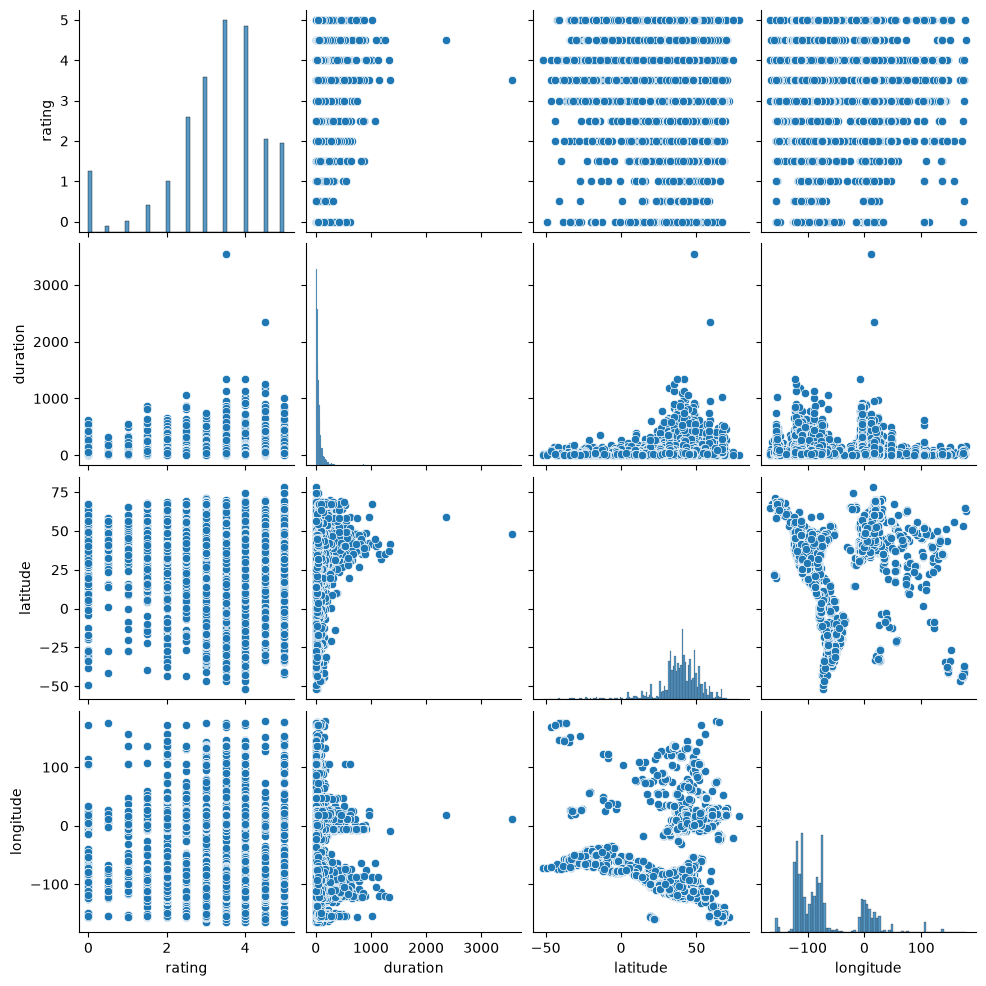

In [52]:
# doesn't actually show any patterns we can immediately discern because a majority of our features are strings
import seaborn as sns
sns.pairplot(data=drop_df)

<Axes: xlabel='longitude', ylabel='latitude'>

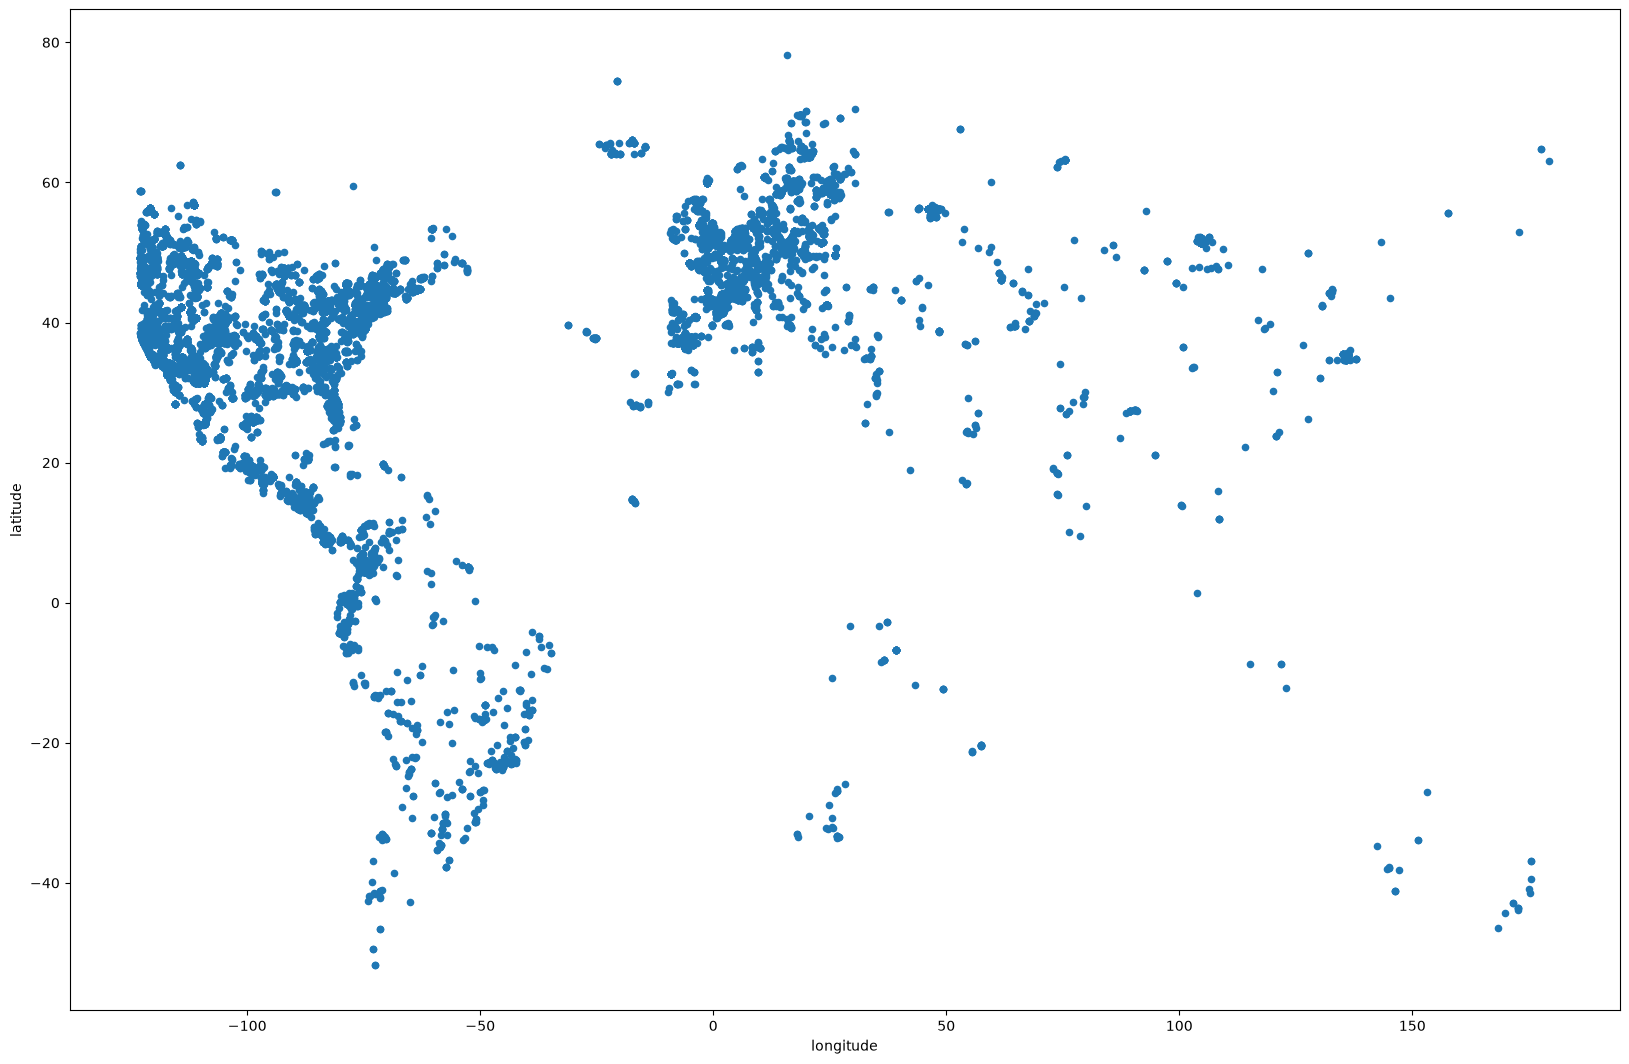

In [53]:
#our longitude and latitude map
drop_df[drop_df.longitude >- 123].plot(figsize=(20,13), kind='scatter', x='longitude', y='latitude')

In [11]:
# correlation = df.iloc[:,:-1].corr()